# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

In [2]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Загружаю изображение.

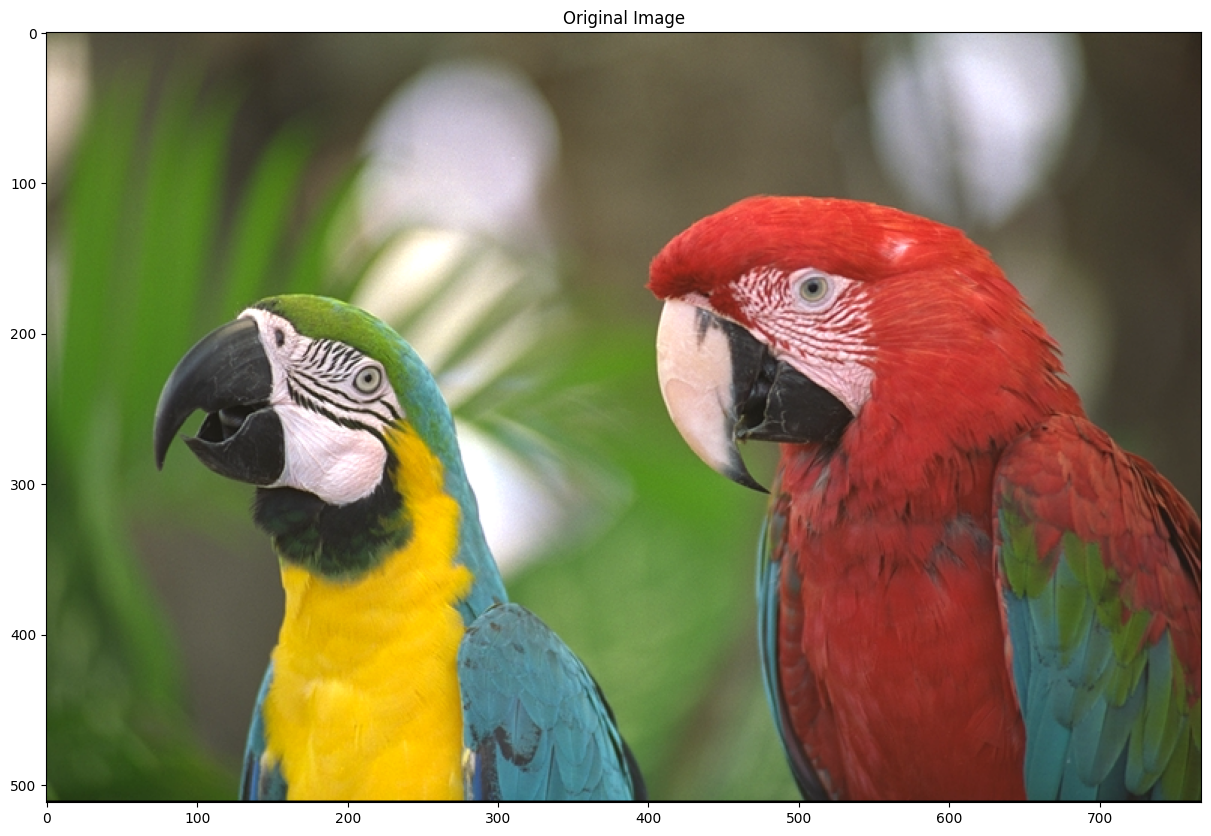

In [3]:
# Загружаю картинку
img = cv2.imread('kodim23.png')
# Конвертирую из BGR в RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Показываю
plt.imshow(img)
plt.title('Original Image')
plt.show()

Начну с серых тонов.

In [5]:
# Палитра: чёрный, тёмно-серый, светло-серый, белый
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Теперь квантую изображение с помощью этой палитры.

In [6]:
# Привожу изображение к float
img = img.astype(np.float64)

# Размеры изображения
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Квантование
for r in range(rows):
    for c in range(cols):
        # Берём значение пикселя
        pixel = img[r, c, :]
        
        # Ищу ближайший цвет из палитры по евклидову расстоянию
        distances = np.sqrt(np.sum((colors - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors[closest_idx]
        
        # Записываю квантованный пиксель
        quantized[r, c, :] = new_pixel

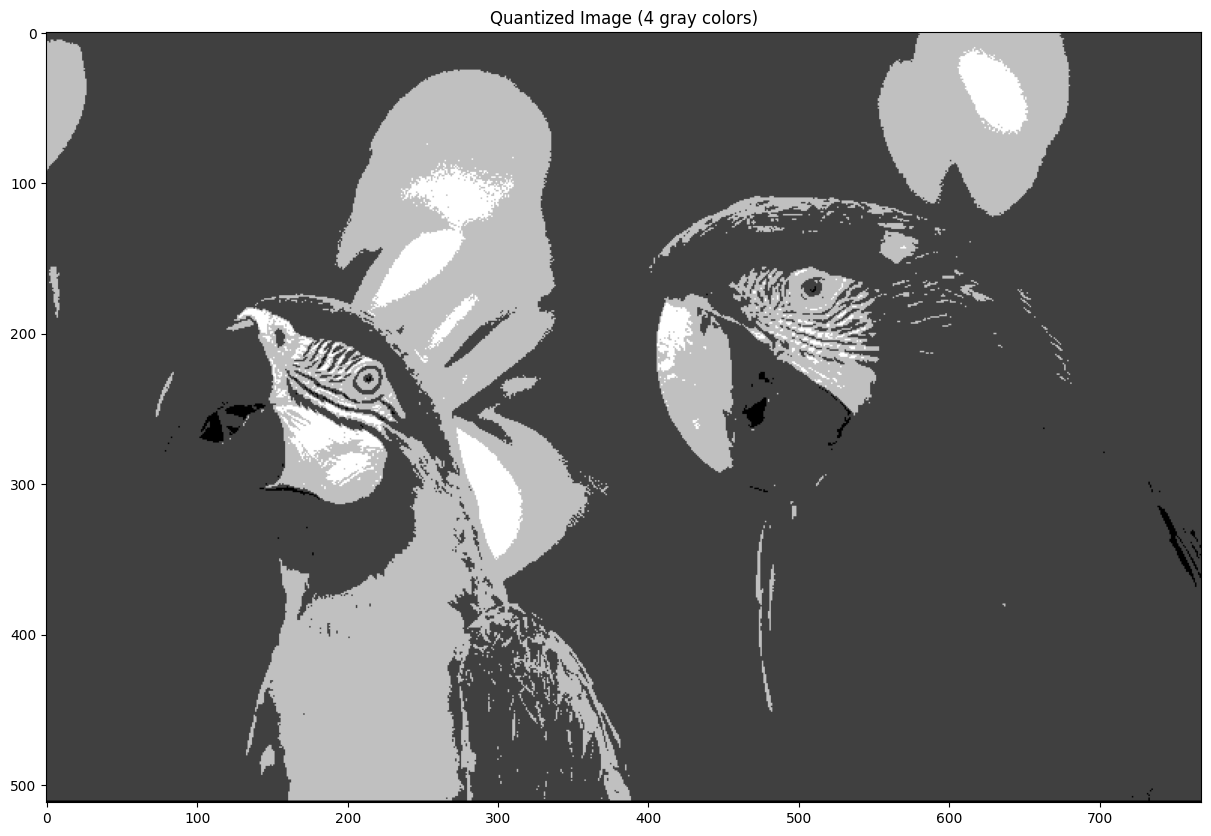

In [7]:
# Показываю квантованное изображение (не забываю привести к uint8)
plt.imshow(quantized.astype(np.uint8))
plt.title('Quantized Image (4 gray colors)')
plt.show()

In [8]:
# Считаю среднюю ошибку квантования
avg_quant_error = np.mean(np.abs(img - quantized))
print(f'Средняя ошибка квантования: {avg_quant_error:.4f}')

Средняя ошибка квантования: 32.7578


#### Floyd-Steinberg Dithering
Теперь реализую дизеринг Флойда-Стейнберга и сравню его с квантованным изображением выше.

In [9]:
# Копия оригинала для диффузии ошибки
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Берём пиксель (уже с накопленной ошибкой от соседей)
        pixel = img_tmp[r, c, :]
        
        # Ищу ближайший цвет из палитры
        distances = np.sqrt(np.sum((colors - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors[closest_idx].astype(np.float64)
        
        # Считаю ошибку квантования
        quant_error = pixel - new_pixel
        
        # Распределяю ошибку по соседям по матрице FS:
        #        *   7/16
        # 3/16  5/16  1/16
        img_tmp[r,     c + 1, :] += quant_error * 7.0 / 16.0
        img_tmp[r + 1, c - 1, :] += quant_error * 3.0 / 16.0
        img_tmp[r + 1, c,     :] += quant_error * 5.0 / 16.0
        img_tmp[r + 1, c + 1, :] += quant_error * 1.0 / 16.0
        
        # Записываю результат
        dithering[r, c, :] = new_pixel

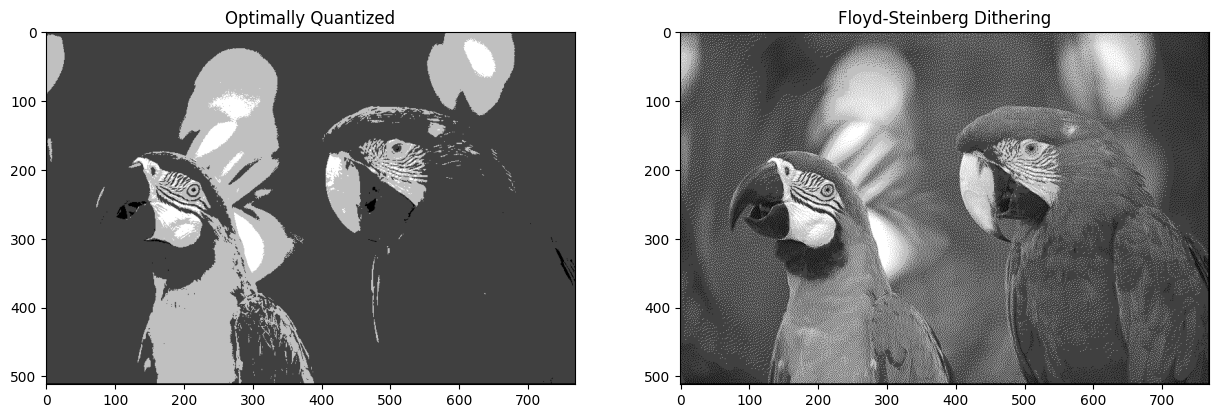

In [10]:
# Сравниваю квантованное и дизеринг-изображение
plt.subplot(121), plt.imshow(quantized.astype(np.uint8))
plt.title('Optimally Quantized')
plt.subplot(122), plt.imshow(dithering.astype(np.uint8))
plt.title('Floyd-Steinberg Dithering')
plt.show()

In [11]:
# Средняя ошибка квантования для дизеринга
avg_dith_error = np.mean(np.abs(img - dithering))
print(f'Средняя ошибка (квантование): {avg_quant_error:.4f}')
print(f'Средняя ошибка (дизеринг):    {avg_dith_error:.4f}')

Средняя ошибка (квантование): 32.7578
Средняя ошибка (дизеринг):    41.8308


### Вопросы

**Какое изображение имеет большую ошибку квантования — оптимально квантованное или с дизерингом?**

Ошибка больше у дизеринга. Это логично, потому что при обычном квантовании каждый пиксель заменяется на ближайший цвет, а при дизеринге мы специально раскидываем ошибку по соседям, и из-за этого общий шум увеличивается.

**Какое изображение выглядит лучше?**

Мне кажется, дизеринг выглядит намного приятнее. Хоть ошибка и больше, но картинка смотрится более плавной, без резких полос между цветами. Глаз воспринимает её как более детальную.

**Можно ли повторить то же самое с двумя цветами — чёрным и белым?**

Да, конечно! Делаю ниже.

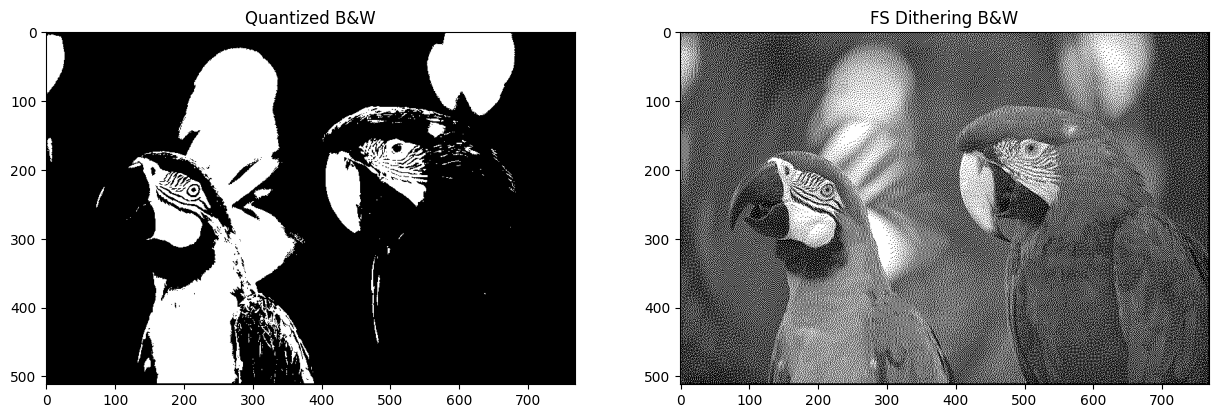

Средняя ошибка (ч/б квантование): 82.0559
Средняя ошибка (ч/б дизеринг):    106.1818


In [12]:
# Палитра: только чёрный и белый
colors_bw = np.array([[0, 0, 0],
                      [255, 255, 255]])

# --- Квантование ч/б ---
quantized_bw = np.zeros_like(img)
for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        distances = np.sqrt(np.sum((colors_bw - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        quantized_bw[r, c, :] = colors_bw[closest_idx]

# --- FS дизеринг ч/б ---
img_tmp_bw = np.copy(img)
dithering_bw = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = img_tmp_bw[r, c, :]
        distances = np.sqrt(np.sum((colors_bw - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors_bw[closest_idx].astype(np.float64)
        
        quant_error = pixel - new_pixel
        
        img_tmp_bw[r,     c + 1, :] += quant_error * 7.0 / 16.0
        img_tmp_bw[r + 1, c - 1, :] += quant_error * 3.0 / 16.0
        img_tmp_bw[r + 1, c,     :] += quant_error * 5.0 / 16.0
        img_tmp_bw[r + 1, c + 1, :] += quant_error * 1.0 / 16.0
        
        dithering_bw[r, c, :] = new_pixel

# Результат
plt.subplot(121), plt.imshow(quantized_bw.astype(np.uint8))
plt.title('Quantized B&W')
plt.subplot(122), plt.imshow(dithering_bw.astype(np.uint8))
plt.title('FS Dithering B&W')
plt.show()

print(f'Средняя ошибка (ч/б квантование): {np.mean(np.abs(img - quantized_bw)):.4f}')
print(f'Средняя ошибка (ч/б дизеринг):    {np.mean(np.abs(img - dithering_bw)):.4f}')

### Бонус

Повторяю то же самое, но с оптимальной палитрой через k-means.

In [13]:
from sklearn.cluster import KMeans

# Нахожу 16 оптимальных цветов через k-means
kmeans_16 = KMeans(n_clusters=16, random_state=42, n_init=10).fit(np.reshape(img, (-1, 3)))
colors_16 = kmeans_16.cluster_centers_
print(f'16 оптимальных цветов:\n{colors_16}')

16 оптимальных цветов:
[[ 62.75058241  61.84246794  45.54947399]
 [171.23280486 165.57776861 157.2320976 ]
 [ 86.19574584 124.50447232  41.61753477]
 [235.46818204 187.9772215   11.26576512]
 [153.35421953  55.29292149  48.16105902]
 [239.57246011 228.67535562 231.05256697]
 [ 89.7003048  140.85237664 147.82354395]
 [ 63.16084685  97.06039776  95.01805517]
 [113.27238575  45.4235231   37.27589481]
 [ 75.84572342  88.97844391  50.16456168]
 [211.76441605 195.48340462 194.0498132 ]
 [ 42.69472576  39.74730617  32.77315077]
 [137.21516598 137.72693901 113.86160785]
 [100.53292239  96.29601893  72.69926525]
 [208.14408487  69.23032243  58.95572546]
 [111.0116955  141.02972606  73.8050054 ]]


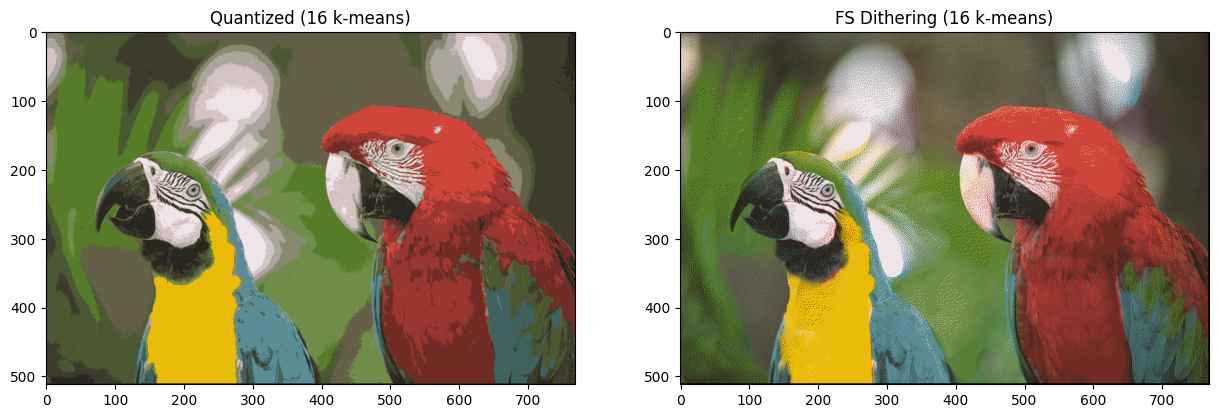

Средняя ошибка (16 цветов, квантование): 9.0662
Средняя ошибка (16 цветов, дизеринг):    16.5829


In [14]:
# --- Квантование с 16 цветами k-means ---
quantized_16 = np.zeros_like(img)
for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        distances = np.sqrt(np.sum((colors_16 - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        quantized_16[r, c, :] = colors_16[closest_idx]

# --- FS дизеринг с 16 цветами k-means ---
img_tmp_16 = np.copy(img)
dithering_16 = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = img_tmp_16[r, c, :]
        distances = np.sqrt(np.sum((colors_16 - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors_16[closest_idx].astype(np.float64)
        
        quant_error = pixel - new_pixel
        
        img_tmp_16[r,     c + 1, :] += quant_error * 7.0 / 16.0
        img_tmp_16[r + 1, c - 1, :] += quant_error * 3.0 / 16.0
        img_tmp_16[r + 1, c,     :] += quant_error * 5.0 / 16.0
        img_tmp_16[r + 1, c + 1, :] += quant_error * 1.0 / 16.0
        
        dithering_16[r, c, :] = new_pixel

# Результат
plt.subplot(121), plt.imshow(quantized_16.astype(np.uint8))
plt.title('Quantized (16 k-means)')
plt.subplot(122), plt.imshow(dithering_16.astype(np.uint8))
plt.title('FS Dithering (16 k-means)')
plt.show()

print(f'Средняя ошибка (16 цветов, квантование): {np.mean(np.abs(img - quantized_16)):.4f}')
print(f'Средняя ошибка (16 цветов, дизеринг):    {np.mean(np.abs(img - dithering_16)):.4f}')

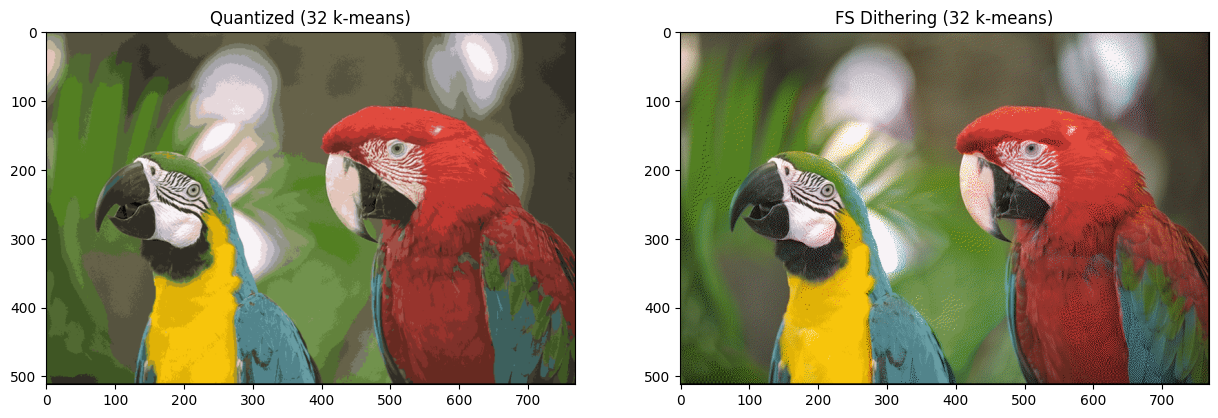

Средняя ошибка (32 цвета, квантование): 6.7511
Средняя ошибка (32 цвета, дизеринг):    14.0909


In [15]:
# --- 32 цвета k-means ---
kmeans_32 = KMeans(n_clusters=32, random_state=42, n_init=10).fit(np.reshape(img, (-1, 3)))
colors_32 = kmeans_32.cluster_centers_

img_tmp_32 = np.copy(img)
dithering_32 = np.zeros_like(img)
quantized_32 = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        distances = np.sqrt(np.sum((colors_32 - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        quantized_32[r, c, :] = colors_32[closest_idx]

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = img_tmp_32[r, c, :]
        distances = np.sqrt(np.sum((colors_32 - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors_32[closest_idx].astype(np.float64)
        
        quant_error = pixel - new_pixel
        
        img_tmp_32[r,     c + 1, :] += quant_error * 7.0 / 16.0
        img_tmp_32[r + 1, c - 1, :] += quant_error * 3.0 / 16.0
        img_tmp_32[r + 1, c,     :] += quant_error * 5.0 / 16.0
        img_tmp_32[r + 1, c + 1, :] += quant_error * 1.0 / 16.0
        
        dithering_32[r, c, :] = new_pixel

plt.subplot(121), plt.imshow(quantized_32.astype(np.uint8))
plt.title('Quantized (32 k-means)')
plt.subplot(122), plt.imshow(dithering_32.astype(np.uint8))
plt.title('FS Dithering (32 k-means)')
plt.show()

print(f'Средняя ошибка (32 цвета, квантование): {np.mean(np.abs(img - quantized_32)):.4f}')
print(f'Средняя ошибка (32 цвета, дизеринг):    {np.mean(np.abs(img - dithering_32)):.4f}')

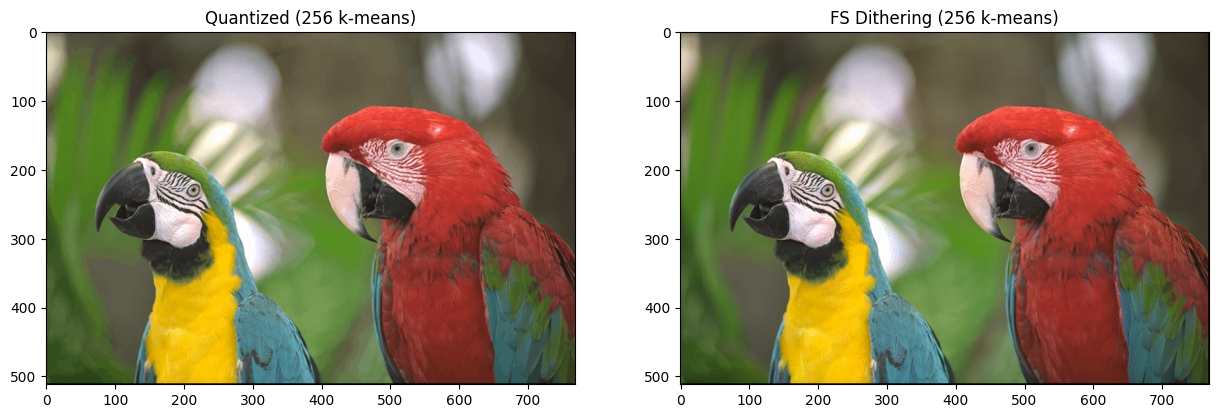

Средняя ошибка (256 цветов, квантование): 2.7957
Средняя ошибка (256 цветов, дизеринг):    5.0260


In [16]:
# --- 256 цветов k-means ---
kmeans_256 = KMeans(n_clusters=256, random_state=42, n_init=10).fit(np.reshape(img, (-1, 3)))
colors_256 = kmeans_256.cluster_centers_

img_tmp_256 = np.copy(img)
dithering_256 = np.zeros_like(img)
quantized_256 = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        distances = np.sqrt(np.sum((colors_256 - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        quantized_256[r, c, :] = colors_256[closest_idx]

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = img_tmp_256[r, c, :]
        distances = np.sqrt(np.sum((colors_256 - pixel) ** 2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors_256[closest_idx].astype(np.float64)
        
        quant_error = pixel - new_pixel
        
        img_tmp_256[r,     c + 1, :] += quant_error * 7.0 / 16.0
        img_tmp_256[r + 1, c - 1, :] += quant_error * 3.0 / 16.0
        img_tmp_256[r + 1, c,     :] += quant_error * 5.0 / 16.0
        img_tmp_256[r + 1, c + 1, :] += quant_error * 1.0 / 16.0
        
        dithering_256[r, c, :] = new_pixel

plt.subplot(121), plt.imshow(quantized_256.astype(np.uint8))
plt.title('Quantized (256 k-means)')
plt.subplot(122), plt.imshow(dithering_256.astype(np.uint8))
plt.title('FS Dithering (256 k-means)')
plt.show()

print(f'Средняя ошибка (256 цветов, квантование): {np.mean(np.abs(img - quantized_256)):.4f}')
print(f'Средняя ошибка (256 цветов, дизеринг):    {np.mean(np.abs(img - dithering_256)):.4f}')

### Ответы на бонусные вопросы

**Как выглядит результат с 16 цветами k-means?**

С 16 оптимальными цветами результат уже намного лучше, чем с 4 серыми. Палитра подобрана под саму картинку, поэтому основные цвета сохраняются. А с дизерингом переходы между цветами выглядят ещё мягче.

**Что будет с 32 цветами?**

С 32 цветами качество заметно улучшается. Переходы становятся более плавными, мелкие детали лучше видны. С дизерингом картинка уже почти как оригинал.

**А с 256 цветами?**

С 256 цветами разницу с оригиналом практически не видно. Ошибка квантования совсем маленькая, и дизеринг уже почти ничего не меняет визуально.